In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import regionsUtilities as rg
import matplotlib.pyplot as plt

In [12]:
# load data
batch_file = '/mnt/hubel-data-103/Pietro/Data/BatchFiles/IS_units.batch'
true, prediction, score, X = rg.runBatch(batch_file,rg._ISRPopulationGLM,[[3]],verbose=False,sessions=[15])
true = true[0]
prediction = prediction[0]
score = score[0]
X = X[0]

In [5]:
score['hpc']

array([[ 0.09726968],
       [-0.02797276],
       [ 0.26081811],
       [ 0.32837086],
       [ 0.28187826]])

In [14]:
np.mean(score['nr'],0), np.mean(score['hpc'],0), np.mean(score['pfc'],0) # nREM WORKSSS with window 0.1 I presume

(array([0.73732299, 0.87850101, 0.99987655, 0.88073224, 0.74462084]),
 array([0.18459072, 0.18732263, 0.1881419 , 0.18669913, 0.18211264]),
 array([0.14046336, 0.15672748, 0.16377292, 0.15769482, 0.14400861]))

Recap:
nREM worked well with interactions, it just fails to predict low values of y but works very well on high y fluctuations, what happens there??
try reducing the time window!
delay seems useless for now, but maybe I usee a delay too big

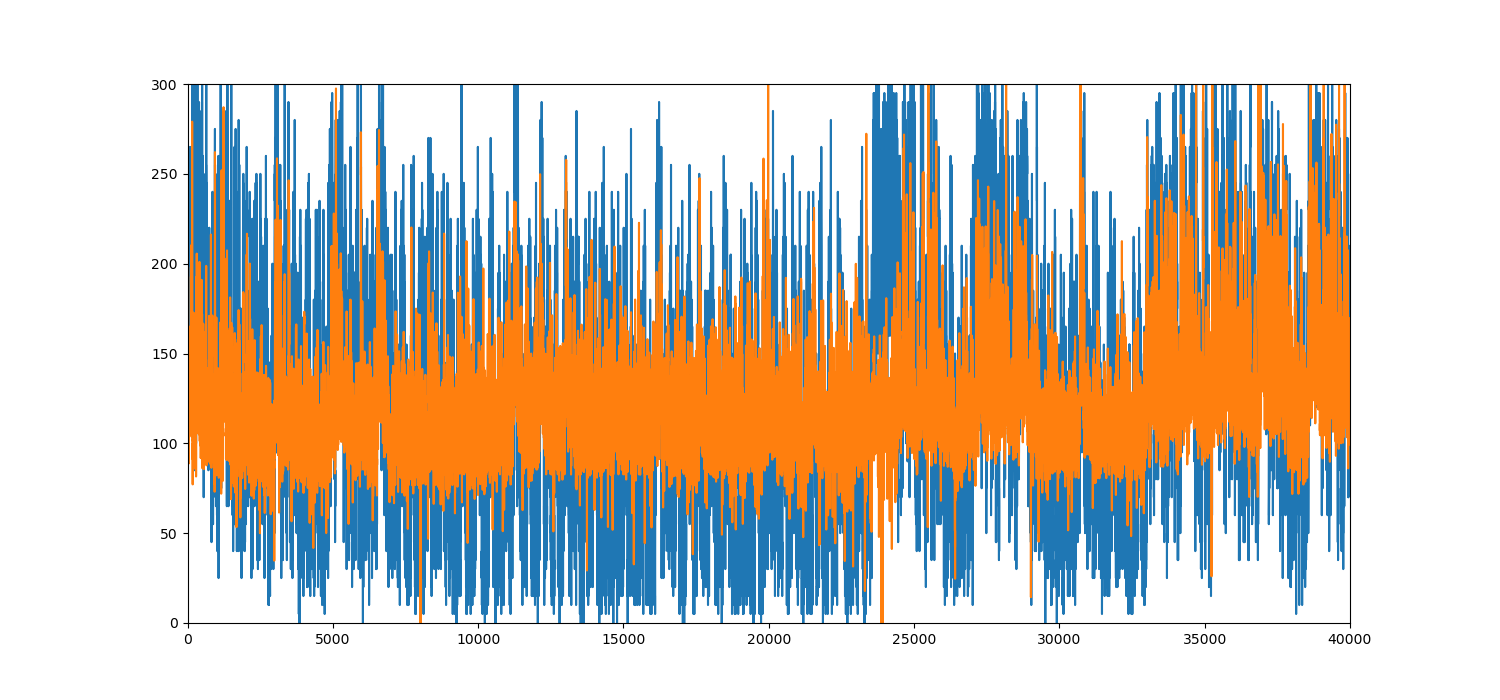

In [16]:
fig, axs = plt.subplots(1,1,figsize=[15,7])
start = 0
stop = 40000
key = 'pfc'
axs.plot(range(start,stop),true[start:stop])
axs.plot(range(start,stop),prediction[key][start:stop])
# plot unit activity
#axs.plot(range(start,stop),X[key][start:stop,10])
#axs.plot(range(start,stop),X[key][start:stop,23])
#axs.plot(range(start,stop),X[key][start:stop,37])
# plot summed population activity
#axs.plot(range(start,stop),np.sum(X[key],1)[start:stop])
axs.set_xlim([start,stop]); axs.set_ylim([0,300]);
#plt.show()

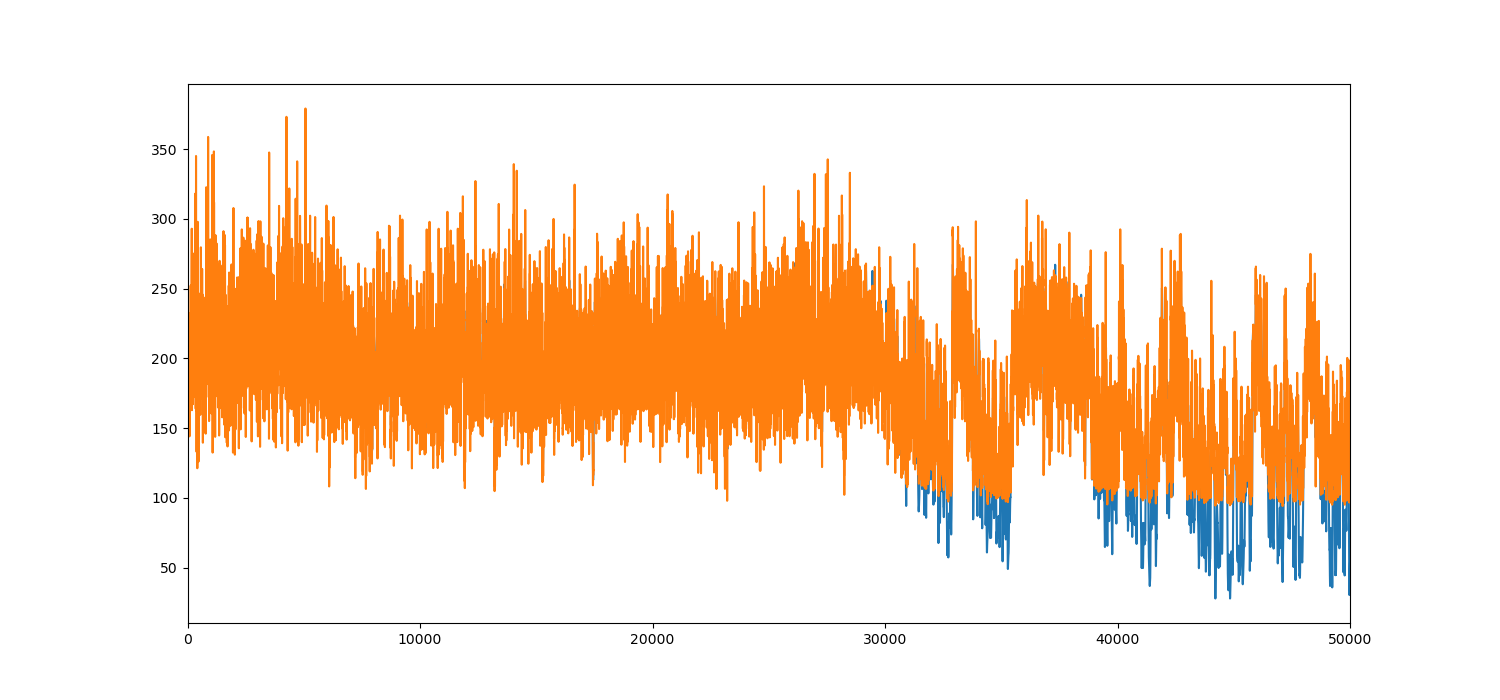

In [10]:
fig, axs = plt.subplots(1,1,figsize=[15,7])
start = 0
stop = 50000
axs.plot(true[start:stop])
#axs.plot(prediction['hpc'][start:stop])
#axs.plot(prediction['pfc'][start:stop])
axs.plot(prediction['nr'][start:stop])
axs.set_xlim([start,stop]);
plt.show()